# CIFAR-100 Image Classification with **CNN** and **Data Augmentation**

In [12]:
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt
from keras.optimizers import Adam
from keras.models import Sequential
from keras.datasets import cifar100
from sklearn.model_selection import train_test_split
from keras.layers import (Conv2D, Activation, BatchNormalization,
                          MaxPooling2D, GlobalAveragePooling2D,
                          Dense, Dropout, Softmax, Input)
from keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Loading the CIFAR-100 Dataset

The CIFAR-100 dataset is loaded using the `fine` label mode, which provides 100 detailed image classes.

The dataset is split into:

- **Training set:** used to train the CNN model.
- **Test set:** used to evaluate the model on unseen images.

This cell also prints the shapes of the image arrays and label arrays to verify that the dataset has been loaded correctly.

In [2]:
(X_train, y_train), (X_test, y_test) = cifar100.load_data(label_mode= 'fine')
print(f'X_train shape: {X_train.shape}\ny_train shape: {y_train.shape}\n'\
      f'X_test shape: {X_test.shape}\ny_test shape: {y_test.shape}')

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 1396s 8us/step
X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


## Data Normalization
Pixel values are converted to `float32` and scaled from `[0, 255]` to `[0.0, 1.0]` to accelerate model convergence and improve numerical stability during training.


In [3]:
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

## Label Shape Update
The target labels were squeezed from shape `(N, 1)` to `(N,)` for compatibility with model training and evaluation.


In [4]:
y_train = np.squeeze(y_train)
y_test = np.squeeze(y_test)

In [5]:
fine_labels = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee',
    'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus',
    'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle',
    'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch',
    'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant',
    'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo',
    'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard',
    'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse',
    'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree',
    'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy',
    'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road',
    'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk',
    'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar',
    'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone',
    'television', 'tiger', 'tractor', 'train', 'trout', 'tulip',
    'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

## Visualize a CIFAR-100 Image

The `fine_labels` list maps each numeric label to its corresponding class name.  
A selected training image is displayed with its class label.


Enter the number of image: 45000


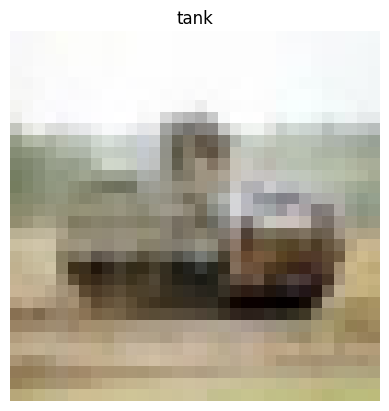

In [6]:
i = int(input('Enter the number of image: '))
plt.imshow(X_train[i])
plt.title(fine_labels[y_train[i]]);
plt.axis('off');

## Splitting the Training Data into Training and Validation Sets

In [49]:
X_train_split, X_val, y_train_split, y_val = train_test_split(X_train_norm, y_train, test_size= 0.1, random_state= 42, stratify= y_train)

In [50]:
X_val = X_val.astype('float32')

### Configuring Data Augmentation

We initialize an `ImageDataGenerator` to apply real-time data transformations to the training dataset. This helps the model generalize better by introducing variations such as flips, shears, zooms, and shifts.

The augmented images are then streamed through `train_datagen.flow()`, which handles batching and shuffling dynamically during training.


In [52]:
train_datagen = ImageDataGenerator(rotation_range= 10,
                                   zoom_range= 0.1,
                                   shear_range= 0.1,
                                   horizontal_flip= True,
                                   vertical_flip= False,
                                   fill_mode= 'nearest',
                                   width_shift_range= 0.1,
                                   height_shift_range= 0.1)

train_generation = train_datagen.flow(X_train_split,
                                      y_train_split,
                                      batch_size= 32,
                                      shuffle= True)

## Model definition

In [53]:
model = Sequential([
    Input(shape= (32, 32, 3)),
    Conv2D(64, (3, 3), padding= 'same', use_bias= False),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(64, (3, 3), padding= 'same', use_bias= False),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.1),
    Conv2D(128, (3, 3), padding= 'same', use_bias= False),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(128, (3, 3), padding= 'same', use_bias= False),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.15),
    Conv2D(256, (3, 3), padding= 'same', use_bias= False),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(256, (3, 3), padding= 'same', use_bias= False),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.2),
    GlobalAveragePooling2D(),
    Dense(256, activation= 'relu'),
    Dropout(0.3),
    Dense(100)
])

In [54]:
model.compile(optimizer= Adam(learning_rate= 0.001),
              loss= SparseCategoricalCrossentropy(from_logits= True),
              metrics= ['acc'])

In [55]:
his = model.fit(train_generation,
                validation_data= (X_val, y_val),
                epochs= 70,
                verbose= 2)

Epoch 1/70
1407/1407 - 59s - 42ms/step - acc: 0.0822 - loss: 3.9881 - val_acc: 0.1142 - val_loss: 3.7936
Epoch 2/70
1407/1407 - 38s - 27ms/step - acc: 0.1566 - loss: 3.4591 - val_acc: 0.1528 - val_loss: 3.5346
Epoch 3/70
1407/1407 - 37s - 26ms/step - acc: 0.2247 - loss: 3.0701 - val_acc: 0.2622 - val_loss: 2.8823
Epoch 4/70
1407/1407 - 37s - 26ms/step - acc: 0.2746 - loss: 2.8109 - val_acc: 0.2670 - val_loss: 2.9860
Epoch 5/70
1407/1407 - 41s - 29ms/step - acc: 0.3140 - loss: 2.6214 - val_acc: 0.3502 - val_loss: 2.4922
Epoch 6/70
1407/1407 - 36s - 25ms/step - acc: 0.3474 - loss: 2.4576 - val_acc: 0.3526 - val_loss: 2.5082
Epoch 7/70
1407/1407 - 36s - 26ms/step - acc: 0.3738 - loss: 2.3290 - val_acc: 0.3858 - val_loss: 2.3162
Epoch 8/70
1407/1407 - 37s - 26ms/step - acc: 0.3986 - loss: 2.2223 - val_acc: 0.3804 - val_loss: 2.3303
Epoch 9/70
1407/1407 - 37s - 26ms/step - acc: 0.4227 - loss: 2.1256 - val_acc: 0.3818 - val_loss: 2.5468
Epoch 10/70
1407/1407 - 37s - 26ms/step - acc: 0.4408 -

| Metric | Training | Test |
|---|---:|---:|
| Accuracy | **78.64%** | **62.35%** |
| Loss | **0.72** | **1.53** |

In [56]:
train_loss, train_acc = model.evaluate(X_train_norm, y_train)
test_loss, test_acc = model.evaluate(X_test_norm, y_test)

print(f'Train Accuracy: {train_acc * 100:.2f}%\nTest Accuracy: {test_acc * 100:.2f}%\n'\
      f'Train Loss: {train_loss:.2f}\nTest Loss: {test_loss:.2f}')

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.7864 - loss: 0.7238
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.6235 - loss: 1.5343
Train Accuracy: 78.64%
Test Accuracy: 62.35%
Train Loss: 0.72
Test Loss: 1.53


In [57]:
model.save('cifar_model.keras')